In [1]:
import traci
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [12]:
SUMO_BINARY = "sumo"
SUMO_CONFIG = "simulation.sumocfg"
SIM_END = 4500
CONTROL_STEP = 15

NUM_LANES = 4

In [11]:
RAMPS = {
    "Ramp 1": {
        "loc": (1, 1),
        "x_range": (1400, 3600),
        "q0": 10356,
        "detectors": {
            "up":  {"ids": [f"det_a1_up_{i}"  for i in range(4)], "shift": 0},
            "down1": {"ids": [f"det_a1_dn1_{i}" for i in range(4)],   "shift": 30},
            "down2": {"ids": [f"det_a1_dn2_{i}" for i in range(4)],   "shift": 58},
        },
    },
    "Ramp 2": {
        "loc": (0, 1),
        "x_range": (2100, 4600),
        "q0": 9432,
        "detectors": {
            "up": {"ids": [f"det_a2_up_{i}"  for i in range(4)], "shift": 0},
            "down1": {"ids": [f"det_a2_dn1_{i}" for i in range(1, 5)], "shift": 29},
            "down2": {"ids": [f"det_a2_dn2_{i}" for i in range(4)],   "shift": 51},
        },
    },
    "Ramp 3": {
        "loc": (1, 0),
        "x_range": (1500, 3900),
        "q0": 8472,
        "detectors": {
            "up": {"ids": [f"det_a3_up_{i}"  for i in range(4)]
                        , "shift": 0},
            "down1": {"ids": [f"det_a3_dn1_{i}" for i in range(4)],   "shift": 22},
            "down2": {"ids": [f"det_a3_dn2_{i}" for i in range(1, 5)], "shift": 43},
        },
    },
    "Ramp 4": {
        "loc": (0, 0),
        "x_range": (1000, 3900),
        "q0": 6204,
        "detectors": {
            "up": {"ids": [f"det_a4_up_{i}"  for i in range(4)], "shift": 0},
            "down1": {"ids": [f"det_a4_dn1_{i}" for i in range(4)],   "shift": 39},
            "down2": {"ids": [f"det_a4_dn2_{i}" for i in range(4)],   "shift": 62},
        },
    },
}

In [ ]:
# ----------- SIMULATION -----------

times = []

history = {
    "Ramp 1": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 2": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 3": {
            "up": [], "down1": [], "down2": []
        },
    "Ramp 4": {
            "up": [], "down1": [], "down2": []
        },
}

In [5]:
def getAllVehCounts(history):
    for ramp_name, item in RAMPS.items():
        up_ids = item['detectors']['up']['ids']
        down1_ids = item['detectors']['down1']['ids']
        down2_ids = item['detectors']['down2']['ids']

        up_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in up_ids])/4
        down1_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in down1_ids])/4
        down2_count = np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in down2_ids])/4

        history[ramp_name]['up'].append(up_count)
        history[ramp_name]['down1'].append(down1_count)
        history[ramp_name]['down2'].append(down2_count)

    return history


In [6]:
traci.start([SUMO_BINARY, "-c", SUMO_CONFIG])

for i in tqdm(range(SIM_END)):
    # if i % CONTROL_STEP == 0 and i != 0:
    history = getAllVehCounts(history)

    times.append(i)

    traci.simulationStep()

traci.close()

 Retrying in 1 seconds
***Starting server on port 53685 ***
Loading net-file from 'network.net.xml' ... done (7ms).
Loading additional-files from 'detectors.add.xml' ... done (2ms).
Loading route-files incrementally from 'routes.rou.xml'
Loading done.
Simulation version 1.26.0 started with time: 0.00.


100%|██████████| 4500/4500 [00:26<00:00, 167.13it/s]

Simulation ended at time: 4500.00.
Reason: TraCI requested termination.
Performance:
 Duration: 26.95s
 TraCI-Duration: 18.09s
 Real time factor: 167.001
 UPS: 85891.672233
Vehicles:
 Inserted: 4150
 Running: 0
 Waiting: 0


In [16]:
def getPlotValues(cfg, ramp_history, times):
    SHIFT_DN1 = cfg['detectors']['down1']['shift']
    SHIFT_DN2 = cfg['detectors']['down2']['shift']

    plot_values = {
        'up': {'x': times, 'y': []},
        'down1': {'x': times-SHIFT_DN1, 'y': []},
        'down2': {'x': times-SHIFT_DN2, 'y': []},
    }

    q0 = cfg['q0'] / 3600.0 / NUM_LANES

    up_cumsum = np.cumsum(np.asarray(ramp_history['up']))
    down1_cumsum = np.cumsum(np.asarray(ramp_history['down1']))
    down2_cumsum = np.cumsum(np.asarray(ramp_history['down2']))

    # Calculate modified cumulative arrivals N'(x,t)
    plot_values['up']['y'] = up_cumsum - (q0 * times)
    plot_values['down1']['y'] = down1_cumsum - (q0 * times)
    plot_values['down2']['y'] = down2_cumsum - (q0 * times)


    return plot_values

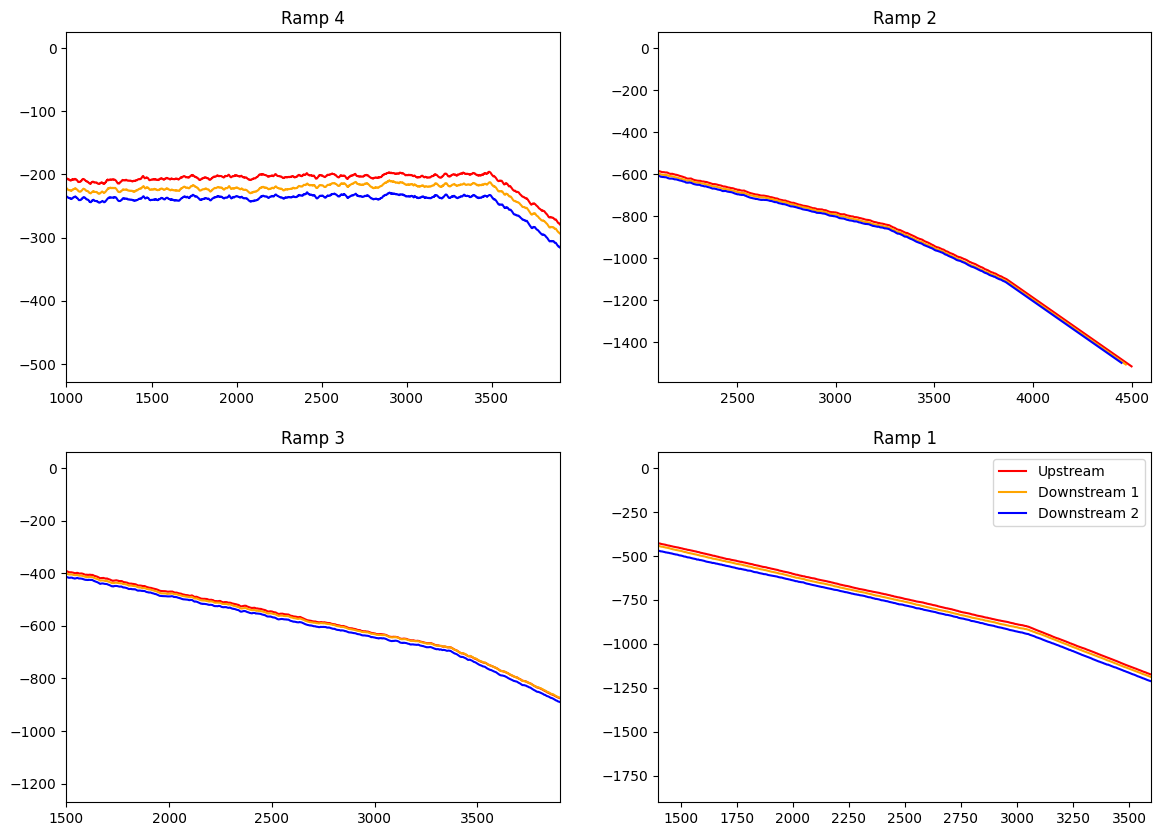

In [ ]:
times = np.asarray(times)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ramp_name, cfg in RAMPS.items():
    row, col = cfg["loc"]

    ax = axs[row,col]

    plot_values = getPlotValues(cfg, history[ramp_name], times)

    # Shift the downstream curves to the left (backward in time)
    ax.plot(plot_values['up']['x'], plot_values['up']['y'], color="r", label="Upstream")
    ax.plot(plot_values['down1']['x'], plot_values['down1']['y'], color="orange", label="Downstream 1")
    ax.plot(plot_values['down2']['x'], plot_values['down2']['y'], color="b", label="Downstream 2")

    ax.set_xlim(cfg['x_range'])
    ax.set_title(ramp_name)

plt.legend()

plt.savefig(os.path.join("plot", "fig_13.png"))
plt.show()